In [1]:
!pip install rioxarray

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [12]:
# load data
ds = xr.open_dataset('ncdiffusion_hourly_pertransect.nc')  

In [13]:
ds

<xarray.Dataset> Size: 15GB
Dimensions:      (time: 385714, site: 9579)
Coordinates:
  * time         (time) datetime64[ns] 3MB 1980-01-01 ... 2023-12-31T23:00:00
  * site         (site) <U16 613kB 'usa_NC_0001_0001' ... 'usa_NC_0049_0230'
    lat          (site) float64 77kB ...
    lon          (site) float64 77kB ...
Data variables:
    diffusivity  (time, site) float32 15GB ...

In [14]:
# perpare landsat mosaic
red_files = ['LC08_L2SP_014035_20170409_20200904_02_T1_SR_B4.TIF', 'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B4.TIF', 'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B4.TIF', 'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B4.TIF']
green_files = ['LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF', 'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF', 'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B3.TIF', 'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B3.TIF']
blue_files = ['LC08_L2SP_014035_20170409_20200904_02_T1_SR_B2.TIF', 'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B2.TIF', 'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B2.TIF', 'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B2.TIF']

def mosaic_band(file_list):
    """Opens a list of TIFs and merges them into one array."""
    elements = [rxr.open_rasterio(f, masked=True).squeeze() for f in file_list]
    return merge_arrays(elements)

print("Mosaicking bands... ")
merged_red = mosaic_band(red_files)
merged_green = mosaic_band(green_files)
merged_blue = mosaic_band(blue_files)

rgb = xr.concat([merged_red, merged_green, merged_blue], dim='band')
rgb['band'] = [1, 2, 3]

rgb_scaled = (rgb / 20000).clip(0, 1)
print('Done! :)')

Mosaicking bands... 
Done! :)


/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/matplotlib/cm.py:489: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


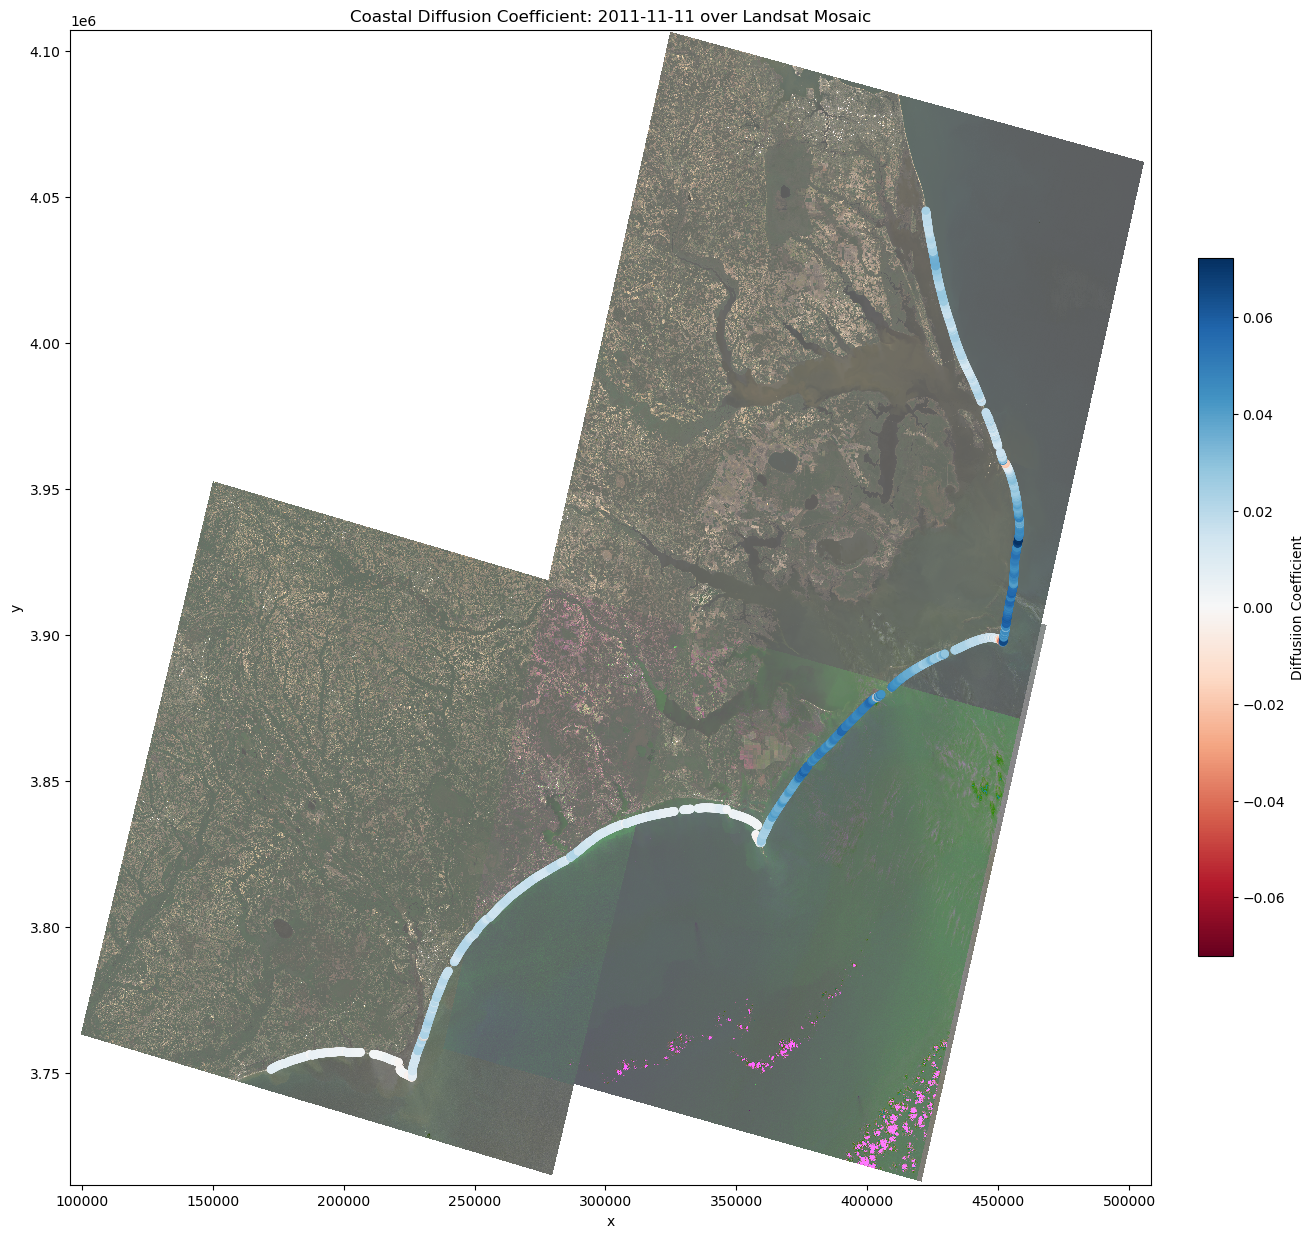

In [15]:
# plot for one time value
target_date = "2011-11-11"
snapshot = ds['diffusivity'].sel(time=target_date, method='nearest').squeeze()
lon = ds['lon']
lat = ds['lat']


gdf = gpd.GeoDataFrame(
    {'diffusivity': snapshot.values},
    geometry=gpd.points_from_xy(lon, lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = max(abs(np.nanmax(snapshot.values)), abs(np.nanmin(snapshot.values)))
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['diffusivity'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Diffusiion Coefficient', fraction=0.03, pad=0.04)
plt.title(f"Coastal Diffusion Coefficient: {target_date} over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()

/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/matplotlib/cm.py:489: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


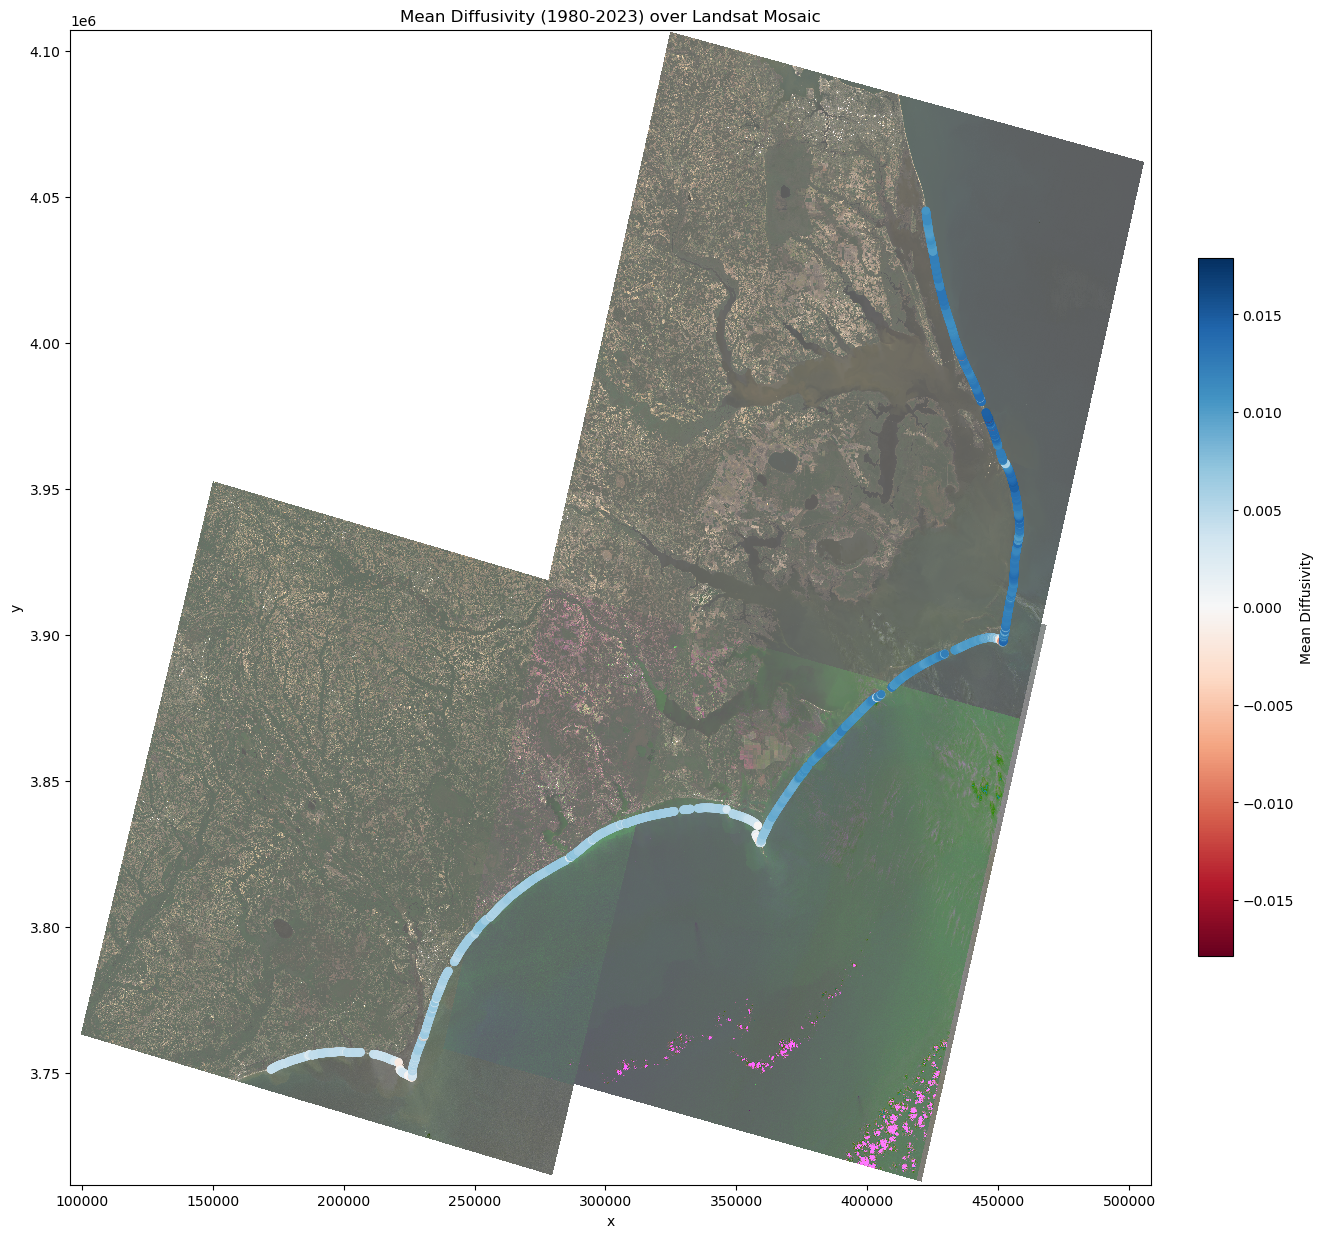

In [16]:
mean_transport = ds['diffusivity'].mean(dim='time').compute()
mean_lon = ds['lon']
mean_lat = ds['lat']

gdf = gpd.GeoDataFrame(
    {'diffusivity': mean_transport.values},
    geometry=gpd.points_from_xy(mean_lon, mean_lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = max(abs(np.nanmax(mean_transport)), abs(np.nanmin(mean_transport)))
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['diffusivity'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Mean Diffusivity', fraction=0.03, pad=0.04)
plt.title(f"Mean Diffusivity (1980-2023) over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()